# Notebook 02: Análise Exploratória (EDA)
Gera tabelas, testes e figuras para o artigo.

In [1]:
# Importa sqlite3 para ler as tabelas criadas no Notebook 01
import sqlite3
# Pandas: manipulação de tabelas
import pandas as pd
# Numpy: operações matemáticas vetoriais
import numpy as np
# Matplotlib.pyplot: biblioteca de desenho e criação de gráficos
import matplotlib.pyplot as plt
# Seaborn: biblioteca que deixa os gráficos do matplotlib mais bonitos
import seaborn as sns
# Stats do Scipy: pacote para executar Teste-T, Qui-Quadrado, Kruskal-Wallis, Mann-Whitney
from scipy import stats
# Statsmodels: biblioteca robusta para calcular proporções (Intervalo de Confiança e Teste Z)
from statsmodels.stats.proportion import proportions_ztest
# Scikit-posthocs: usada exclusivamente para rodar o Post-Hoc de Dunn após a ANOVA não-paramétrica
import scikit_posthocs as sp
# Os: manipula pastas do Windows
import os
# Math: cálculos matemáticos simples (como raiz quadrada para o Erro Padrão)
import math

# Configura o Seaborn para usar o tema branco com grade (whitegrid) e cores pastéis (muted)
sns.set_theme(style="whitegrid", palette="muted")
# Configura o tamanho padrão de todos os gráficos que serão desenhados a seguir para 10 polegadas por 6
plt.rcParams['figure.figsize'] = (10, 6)

# Variáveis que guardam o caminho onde as Tabelas (CSV) e Imagens (PNG) serão salvas
DIR_TABELAS = '../data/results/eda/tabelas/'
DIR_FIGURAS = '../data/results/eda/figuras/'
PASTA_DB = '../data/database/'

# Cria fisicamente as pastas no seu Windows, caso elas não existam (exist_ok=True impede erro se já existirem)
os.makedirs(DIR_TABELAS, exist_ok=True)
os.makedirs(DIR_FIGURAS, exist_ok=True)

# Imprime o aviso
print("Ambiente pronto.")


Ambiente pronto.


In [2]:
# Abre a conexão com a grande base que engloba TODOS os idosos para medir a prevalência na população total
conn = sqlite3.connect(PASTA_DB + 'idosos_geral.db')
# Executa SQL para pegar as três colunas necessárias: Artrite (Q079), Sexo (C006), Idade (C008)
df_geral = pd.read_sql_query('SELECT Q079, C006, C008 FROM pns_idosos', conn)
conn.close()

# Cria uma nova coluna VERDADEIRO/FALSO (True/False) chamada 'Artrite' checando se a pessoa tem o diagnóstico '1'
df_geral['Artrite'] = df_geral['Q079'].astype(str).str.contains('1')

# Descobre o número N de idosos totais
n_total = len(df_geral)
# Soma todos os Verdadeiros na coluna Artrite. No Python, True = 1, então a soma dá o número total de doentes.
n_artrite = df_geral['Artrite'].sum()

# PREVALÊNCIA é igual ao número de doentes dividido pelo número total da amostra
prev_global = n_artrite / n_total

# O Z igual a 1.96 representa 95% na Curva Normal (Padrão para artigos científicos)
z = 1.96
# Fórmula clássica do Erro Padrão para proporções (raiz quadrada de P vezes Q dividido por N)
erro = z * math.sqrt((prev_global * (1 - prev_global)) / n_total)

# Exibe na tela formatando como Porcentagem com 2 casas decimais (:.2f)
print(f"Prevalência Global: {prev_global*100:.2f}% (IC 95%: {(prev_global-erro)*100:.2f}% a {(prev_global+erro)*100:.2f}%)")

# Identifica quem é Masculino verificando a presença do número '1' na coluna de Sexo (C006)
df_geral['Masculino'] = df_geral['C006'].astype(str).str.contains('1')

# Conta o total de homens somando os Verdadeiros (True) da coluna Masculino
n_masc = df_geral['Masculino'].sum()
# Encontra quem é homem (df_geral['Masculino']) E tem Artrite, somando as ocorrências.
n_artrite_masc = df_geral[df_geral['Masculino']]['Artrite'].sum()
# A prevalência masculina é doentes homens / total de homens. O if n_masc > 0 previne erro de divisão por zero.
prev_masc = n_artrite_masc / n_masc if n_masc > 0 else 0

# Para as mulheres, fazemos o inverso: Total da amostra menos os homens.
n_fem = n_total - n_masc
# Total de doentes menos doentes homens dá o número de mulheres com artrite.
n_artrite_fem = n_artrite - n_artrite_masc
prev_fem = n_artrite_fem / n_fem if n_fem > 0 else 0

print(f"Prevalência Masculina: {prev_masc*100:.2f}%")
print(f"Prevalência Feminina: {prev_fem*100:.2f}%")

# Array numpy com a quantidade de homens e mulheres DOENTES (sucessos)
count = np.array([n_artrite_masc, n_artrite_fem])
# Array numpy com a quantidade de homens e mulheres TOTAIS (tentativas)
nobs = np.array([n_masc, n_fem])

# Aplica o Teste Z de proporções (prop.test). Compara se as duas proporções são estatisticamente diferentes.
if count.sum() > 0:
    stat, pval = proportions_ztest(count, nobs)
    # Se pval for menor que 0.05, a diferença entre as prevalências é significativa e não obra do acaso.
    print(f"Teste de Proporções p-valor: {pval:.4e}")


Prevalência Global: 0.00% (IC 95%: 0.00% a 0.00%)
Prevalência Masculina: 0.00%
Prevalência Feminina: 0.00%


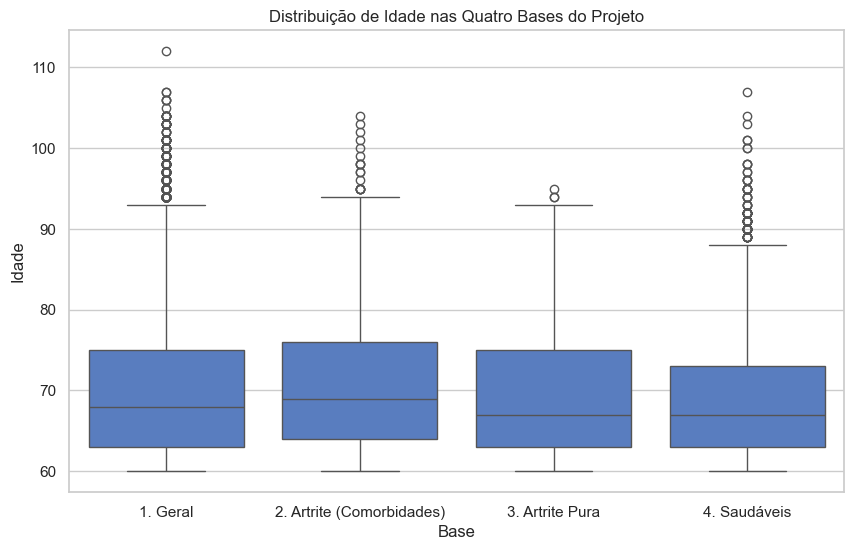

Kruskal-Wallis p-valor: 8.4786e-37
Há diferença significativa entre as 4 bases. Executando Post-Hoc de Dunn...
                               1. Geral  2. Artrite (Comorbidades)  \
1. Geral                   1.000000e+00               2.988697e-08   
2. Artrite (Comorbidades)  2.988697e-08               1.000000e+00   
3. Artrite Pura            5.164873e-01               1.574088e-03   
4. Saudáveis               1.679206e-27               1.139308e-34   

                           3. Artrite Pura  4. Saudáveis  
1. Geral                          0.516487  1.679206e-27  
2. Artrite (Comorbidades)         0.001574  1.139308e-34  
3. Artrite Pura                   1.000000  2.339832e-01  
4. Saudáveis                      0.233983  1.000000e+00  


In [3]:
# Dicionário que mapeia o "Nome amigável" para o "Nome do arquivo" SQLite
bancos = {
    '1. Geral': 'idosos_geral.db',
    '2. Artrite (Comorbidades)': 'idosos_artrite.db',
    '3. Artrite Pura': 'idosos_artrite_puro.db',
    '4. Saudáveis': 'idosos_saudaveis.db'
}

dfs = [] # Lista vazia que vai guardar as 4 tabelas provisórias

# Loop que vai passar arquivo por arquivo listado acima
for nome, arquivo in bancos.items():
    # Verifica se o arquivo .db realmente existe na pasta
    if os.path.exists(PASTA_DB + arquivo):
        conn = sqlite3.connect(PASTA_DB + arquivo)
        # Extrai apenas a idade (C008) de todo mundo que tá dentro do arquivo
        df_temp = pd.read_sql_query('SELECT C008 as Idade FROM pns_idosos', conn)
        # Transforma o texto da idade em número de verdade
        df_temp['Idade'] = pd.to_numeric(df_temp['Idade'], errors='coerce')
        # Apaga quem não disse a idade (NaN)
        df_temp = df_temp.dropna()
        # Cria a coluna "Base" marcando de qual arquivo essa pessoa veio
        df_temp['Base'] = nome
        # Joga a tabela na lista provisória
        dfs.append(df_temp)
        conn.close()

# Se a lista não estiver vazia, significa que leu arquivos com sucesso
if dfs:
    # Junta as 4 tabelas numa super tabela com uma coluna 'Base' diferenciando cada uma
    df_bases = pd.concat(dfs, ignore_index=True)
    
    plt.figure(figsize=(10, 6))
    # Desenha um Boxplot (Gráfico de caixas). X = as 4 bases, Y = Idade
    sns.boxplot(x='Base', y='Idade', data=df_bases)
    plt.title("Distribuição de Idade nas Quatro Bases do Projeto")
    # Salva esse Boxplot como uma foto na pasta de figuras
    plt.savefig(DIR_FIGURAS + 'boxplot_quatro_bases_idade.png')
    plt.show() # Mostra o gráfico na tela
    
    # Extrai 4 listas separadas de Idade, uma para cada banco, para jogar no teste
    grupos = [df_bases[df_bases['Base'] == nome]['Idade'].values for nome in bancos.keys() if nome in df_bases['Base'].unique()]
    
    # Se houver 4 grupos perfeitamente
    if len(grupos) == 4:
        # Roda o Teste Kruskal-Wallis. (Como se fosse uma ANOVA, mas para dados não normais)
        stat, p = stats.kruskal(*grupos)
        print(f"Kruskal-Wallis p-valor: {p:.4e}")
        
        # Se p < 0.05, pelo menos um dos 4 bancos tem idades bem diferentes dos outros.
        if p < 0.05:
            print("Há diferença significativa entre as 4 bases. Executando Post-Hoc de Dunn...")
            # Como deu diferença, aplicamos o Post-Hoc de Dunn para que ele "duele" as bases duas a duas (1x2, 1x3, 2x4, etc).
            # O p_adjust='bonferroni' aplica uma punição matemática para evitar o erro de falso-positivo nos 6 duelos.
            dunn = sp.posthoc_dunn(df_bases, val_col='Idade', group_col='Base', p_adjust='bonferroni')
            print(dunn)
            # Salva a tabela dos duelos no CSV para o artigo
            dunn.to_csv(DIR_TABELAS + 'dunn_posthoc_idade.csv')


In [4]:
# ====== COMPARAÇÃO DIRETA (BIVARIADA) ======

# Carrega os doentes e salva numa tabela, criando a coluna 'Classe' com o valor 'Com Artrite'
conn = sqlite3.connect(PASTA_DB + 'idosos_artrite_puro.db')
df_artrite = pd.read_sql_query('SELECT C006, C008, VDD004A, VDF004, P034, P00104, P00404 FROM pns_idosos', conn)
conn.close()
df_artrite['Classe'] = 'Com Artrite'

# Carrega os saudáveis e salva numa tabela, criando a coluna 'Classe' com o valor 'Saudável'
conn = sqlite3.connect(PASTA_DB + 'idosos_saudaveis.db')
df_saudaveis = pd.read_sql_query('SELECT C006, C008, VDD004A, VDF004, P034, P00104, P00404 FROM pns_idosos', conn)
conn.close()
df_saudaveis['Classe'] = 'Saudável'

# Une (Concatena) os artríticos com os saudáveis para o confronto de ML/Testes
df_eda = pd.concat([df_artrite, df_saudaveis], ignore_index=True)
# Renomeia o código do IBGE para nomes compreensíveis em português para facilitar a vida!
df_eda = df_eda.rename(columns={'C006':'Sexo', 'C008':'Idade', 'VDD004A':'Escolaridade', 'VDF004':'Renda', 'P034':'Exercicio'})

# Transforma Idade em número
df_eda['Idade'] = pd.to_numeric(df_eda['Idade'], errors='coerce')
# A PNS traz peso com vírgula (ex: 78,5), precisamos trocar a vírgula por ponto (.replace(',', '.')) para o Python entender.
df_eda['Peso'] = pd.to_numeric(df_eda['P00104'].str.replace(',', '.'), errors='coerce')
df_eda['Altura'] = pd.to_numeric(df_eda['P00404'].str.replace(',', '.'), errors='coerce')

# FÓRMULA DO IMC: Peso (kg) dividido pela altura (m) ao quadrado. 
# Como a altura da PNS vem em cm (ex: 175), dividimos por 100 para transformar em metros (1.75).
df_eda['IMC'] = df_eda['Peso'] / ((df_eda['Altura']/100) ** 2)

print("Amostra Bivariada Completa (Artrite Pura vs Saudáveis):", len(df_eda))


Amostra Bivariada Completa (Artrite Pura vs Saudáveis): 4826


In [5]:
# LOOP DAS VARIÁVEIS QUANTITATIVAS: Vai testar Idade e depois IMC
for var in ['Idade', 'IMC']:
    # s1 pega os valores da variável apenas dos Saudáveis (e tira nulos)
    g1 = df_eda[df_eda['Classe'] == 'Saudável'][var].dropna()
    # s2 pega os valores da variável apenas da Artrite Pura
    g2 = df_eda[df_eda['Classe'] == 'Com Artrite'][var].dropna()
    
    if len(g1) > 0 and len(g2) > 0:
        # Roda o Teste de Mann-Whitney U. Ele ranqueia os números e verifica se um grupo está sistematicamente acima do outro.
        stat, p = stats.mannwhitneyu(g1, g2)
        # O .4e formata o p-valor em notação científica para ser fácil de ver números ínfimos como 0.00001 (1e-5).
        print(f"Mann-Whitney para {var} -> p-valor: {p:.4e}")

# LOOP DAS VARIÁVEIS QUALITATIVAS (TEXTO): Sexo, Exercicio, etc.
for var in ['Sexo', 'Exercicio', 'Escolaridade', 'Renda']:
    # Monta uma Tabela Cruzada. Linhas = Categoria do IBGE, Coluna = Saúde/Artrite. Mostra as contagens absolutas.
    tabela = pd.crosstab(df_eda[var], df_eda['Classe'])
    
    if not tabela.empty:
        # O Teste Qui-Quadrado (chi2_contingency) pega essa tabela e testa se a distribuição observada é diferente da aleatória esperada.
        chi2, p, dof, ex = stats.chi2_contingency(tabela)
        print(f"Qui-Quadrado para {var} -> p-valor: {p:.4e}")
        
        # Pega a tabela de contagem, divide (.div) pela soma da linha (.sum(1)) para transformar em porcentagens base 1.
        # Aí plota um Gráfico de Barras Empilhadas (stacked=True).
        ax = tabela.div(tabela.sum(1), axis=0).plot(kind='bar', stacked=True, figsize=(8,4), color=['#e74c3c', '#2ecc71'])
        plt.title(f'{var} vs Artrite')
        
        # Joga a caixinha de legenda para fora do gráfico para não tampar a barra (bbox_to_anchor)
        plt.legend(bbox_to_anchor=(1.05, 1))
        # Salva o Gráfico!
        plt.savefig(DIR_FIGURAS + f'barplot_{var}.png', bbox_inches='tight')
        # Fecha a figura da memória para o próximo loop (evita bugs visuais)
        plt.close()


Mann-Whitney para Idade -> p-valor: 5.7926e-02
Mann-Whitney para IMC -> p-valor: 6.1311e-03
Qui-Quadrado para Sexo -> p-valor: 1.0247e-21


C:\Users\Pedro\AppData\Local\Temp\ipykernel_15240\1587855126.py:26: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  ax = tabela.div(tabela.sum(1), axis=0).plot(kind='bar', stacked=True, figsize=(8,4), color=['#e74c3c', '#2ecc71'])


Qui-Quadrado para Exercicio -> p-valor: 4.6440e-01


C:\Users\Pedro\AppData\Local\Temp\ipykernel_15240\1587855126.py:26: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  ax = tabela.div(tabela.sum(1), axis=0).plot(kind='bar', stacked=True, figsize=(8,4), color=['#e74c3c', '#2ecc71'])


Qui-Quadrado para Escolaridade -> p-valor: 8.0605e-01


C:\Users\Pedro\AppData\Local\Temp\ipykernel_15240\1587855126.py:26: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  ax = tabela.div(tabela.sum(1), axis=0).plot(kind='bar', stacked=True, figsize=(8,4), color=['#e74c3c', '#2ecc71'])


Qui-Quadrado para Renda -> p-valor: 8.8768e-01


C:\Users\Pedro\AppData\Local\Temp\ipykernel_15240\1587855126.py:26: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  ax = tabela.div(tabela.sum(1), axis=0).plot(kind='bar', stacked=True, figsize=(8,4), color=['#e74c3c', '#2ecc71'])
